### NWB check

In [20]:
def return_gyro_trial(nwbf, t0, t1):
    # gyro
    gyrodata=nwbf.processing['analog']['analog'].time_series['analog'].data
    gyrotimestamps= np.array(nwbf.processing['analog']['analog'].time_series['analog'].timestamps)

    timestamp_ind = np.logical_and(gyrotimestamps >= t0, gyrotimestamps <= t1)
    gyro_data_trial = gyrodata[timestamp_ind].astype("float64")
    gyro_time_trial = gyrotimestamps[timestamp_ind]

    return gyro_time_trial, gyro_data_trial

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

In [4]:
nwb_file_name = 'molly20220418.nwb'#'lewis20240109.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

In [5]:
# Sensor Data
# nwb
io = pynwb.NWBHDF5IO('/stelmo/nwb/raw/'+nwb_file_name,'r')
nwbf = io.read()

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.4.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cach

In [21]:
t0, t1 = 1650304675, 1650304677# pick immobile time
gyro_time_trial, gyro_data_trial = return_gyro_trial(nwbf, t0, t1)

In [23]:
### need to load video tracking data to find moments with low speed 
low_speed_t = None

In [24]:
gyro_time_trial

array([1.65030468e+09, 1.65030468e+09, 1.65030468e+09, ...,
       1.65030468e+09, 1.65030468e+09, 1.65030468e+09])

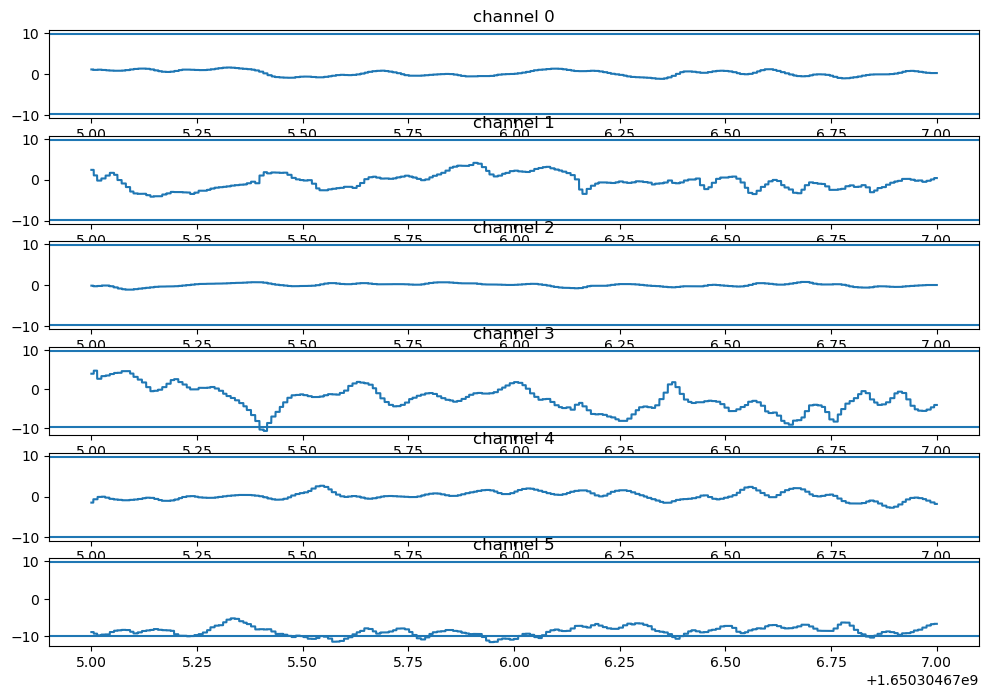

In [25]:
### First, we look for acc_z
### when the animal is still, acc_z should be -9.8
SCALE_FACTOR = 0.000061 * 9.80665 # SCALE_FACTOR for acceleration
fig, axes = plt.subplots(6,1, figsize = (12,8))

for i in range(6):
    axes[i].plot(gyro_time_trial, gyro_data_trial[:,i] * SCALE_FACTOR)
    if low_speed_t is not None:
        axes[i].scatter(gyro_time_trial[low_speed_t], gyro_data_trial[low_speed_t,i] * SCALE_FACTOR,
                    marker = '*', color = 'r', label = "immobility", s = 3)
    axes[i].axhline(9.8)
    axes[i].axhline(-9.8)
    axes[i].set_title(f"channel {i}")

### Conclusion: channel 5 looks like acc_z.